In [4]:
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, Subset, DataLoader
import torch.optim as optim

from tqdm import tqdm
from VAE import VAE, kl_loss_function, mse_loss_function
from UNet import Unet
from DDPM_2D import Diffusion_Scheme

from PIL import Image

import pandas as pd

In [5]:
path = '/home/alzorrcarri/Documentos/diffusion_models/ldp/skin_lession_images'

df_labels = pd.read_csv(path + '/train-metadata.csv', sep = ',', header = 0)
df_labels = df_labels[['isic_id', 'target']]

In [6]:
image_size = 64
device = 'cuda'
epochs = 30

In [7]:
images = []
labels = []
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)), 
    transforms.ToTensor()])

for n_row in range(df_labels.shape[0]):
    image_name, image_label = df_labels.loc[n_row]
    image_path = path + '/train-image/image/' + image_name + '.jpg'
    if os.path.isfile(image_path):
        image = Image.open(image_path)
        image = transform(image)
        images.append(image)
        labels.append(int(image_label))

0


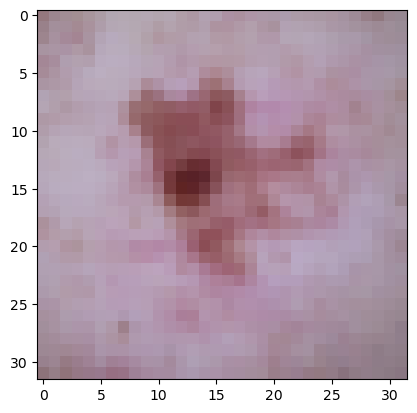

In [8]:
import matplotlib.pyplot as plt

plt.imshow(images[0].permute(1, 2, 0))
print(labels[0])

In [9]:
images[0].shape

torch.Size([3, 32, 32])

In [10]:
len(images), len(labels)

(7496, 7496)

In [11]:
images_tensor = torch.stack(images)
labels_tensor = torch.Tensor(labels)

In [12]:
images_tensor.shape, labels_tensor.shape

(torch.Size([7496, 3, 32, 32]), torch.Size([7496]))

In [13]:
class new_Dataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# Crear el dataset con las imágenes de melanoma de piel
dataset = new_Dataset(images_tensor, labels_tensor)

In [14]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [15]:
def VAE_train(model, dataloader, optimizer, epochs):
    for epoch in range(epochs):
        mse_loss_sum = 0
        kl_loss_sum = 0
        loss_sum = 0
        
        pbar = tqdm(enumerate(dataloader), total=len(dataloader))
        pbar.set_description(f"Epoch {epoch} - Training")
        for i, batch in pbar:
            x, _ = batch
            x = x.to(device)
            mean, log_var = model.encoder(x)
            z_sample = mean + torch.exp(0.5*log_var)*torch.randn(mean.shape).to(device)
            x_bar = model.decoder(z_sample).to(device)

            mse_loss = mse_loss_function(x, x_bar)
            kl_loss = kl_loss_function(mean, log_var)
            loss = torch.mean(mse_loss + kl_loss)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            mse_loss_sum += mse_loss.item()
            kl_loss_sum += kl_loss.item()
            loss_sum += loss.item()
            pbar.set_postfix({'mse_loss' : mse_loss_sum / (i+1), 'kl_loss' : kl_loss_sum / (i+1), 'loss' : loss_sum /(i+1)})

    return model

In [ ]:
model = VAE(image_channels=3, down_channels=[32, 64, 128, 256], mid_channels=[256, 256],
            down_sample=[True, True, True], attn_down=[False, False, False], norm_channels=32, 
            num_heads=16,num_down_layers=1, num_mid_layers=1, num_up_layers=1, latent_channels=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)
model.train()
model = VAE_train(model, dataloader, optimizer, epochs=epochs)

Epoch 29 - Training: 100%|██████████| 235/235 [00:33<00:00,  6.93it/s, mse_loss=908, kl_loss=246, loss=1.15e+3]


In [17]:
torch.save(model.state_dict(), 'VAE_skin.pth')

In [18]:
x = images_tensor[0].unsqueeze(0).to(device)
mean, log_var = model.encoder(x)
z_sample = mean + torch.exp(0.5*log_var)*torch.randn(mean.shape).to(device)
x_bar = model.decoder(z_sample)

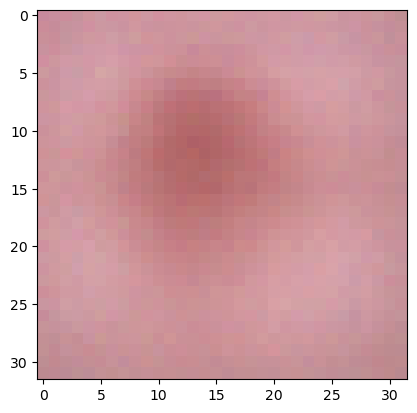

In [19]:
plt.imshow(x_bar[0].permute(1, 2, 0).to('cpu').detach().numpy())

In [20]:
latent_images = []
labels = []

model.eval()
with torch.no_grad():
    for image, label in dataloader:
        image = image.to(device)
        mean, log_var = model.encoder(image)
        latent_images.append(mean)
        labels.append(label)

In [21]:
latent_images = torch.cat(latent_images)
labels = torch.cat(labels)

In [22]:
latent_images.shape, labels.shape

(torch.Size([7496, 5, 8, 8]), torch.Size([7496]))

In [23]:
class LatentDataset(Dataset):
    def __init__(self, latents, labels):
        self.latents = latents
        self.labels = labels

    def __len__(self):
        return len(self.latents)

    def __getitem__(self, idx):
        return self.latents[idx], self.labels[idx]

# Crear el dataset con las codificaciones latentes
latent_dataset = LatentDataset(latent_images, labels)

In [24]:
# Filtrar los índices de las muestras que pertenecen a la clase del 1
indices_clase_1 = [i for i, (img, label) in enumerate(latent_dataset) if label == 1.]

# Crear un dataset con solo esos ejemplos (usando Subset)
latent_dataset_clase_1 = Subset(latent_dataset, indices_clase_1)

latent_dataloader = DataLoader(latent_dataset_clase_1, batch_size=10, shuffle=True)

In [25]:
# Filtrar los índices de las muestras que pertenecen a la clase del 1
indices_clase_0 = [i for i, (img, label) in enumerate(latent_dataset) if label == 0.]

# Crear un dataset con solo esos ejemplos (usando Subset)
latent_dataset_clase_0 = Subset(latent_dataset, indices_clase_0)

latent_dataloader = DataLoader(latent_dataset_clase_0, batch_size=32, shuffle=True)

In [26]:
len(latent_dataset_clase_1), len(latent_dataset_clase_0)

(662, 6834)

In [27]:
unet = Unet(image_channels = latent_images.shape[1], down_channels = [128, 256, 256, 256], mid_channels = [256, 256], time_emb_dim = 256,
            down_sample = [False, False, False], num_down_layers = 2, num_mid_layers = 2, num_up_layers = 2, 
            attn_down = [True, True, True], norm_channels = 32, num_heads = 16, conv_out_channels = 128).to(device)
optimizer = optim.AdamW(unet.parameters(), lr=0.00001)
mse = nn.MSELoss()
diffusion = Diffusion_Scheme(image_size = latent_images.shape[2], device = device, timesteps = 1000, beta1 = 0.0015, betaT = 0.0195, beta_scheme = "linear")

for epoch in range(epochs):
    prog_bar = tqdm(latent_dataloader)
    unet.train()
    loss_mean = 0.0
    for count, (images, _) in enumerate(prog_bar):
        images = images.to(device)
        t = diffusion.sample_timesteps(images.shape[0]).to(device)
        x_t, noise = diffusion.noise_images(images, t)
        predicted_noise = unet(x_t, t)
        loss = mse(noise, predicted_noise)
        loss_mean += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        prog_bar.set_postfix(MSE = loss_mean / (count+1))

100%|██████████| 214/214 [01:24<00:00,  2.53it/s, MSE=0.0126]


In [28]:
torch.save(unet.state_dict(), 'UNet_skin.pth')

Sampleando 10 nuevas imágenes a partir del modelo entrenado...


999it [00:45, 21.96it/s]


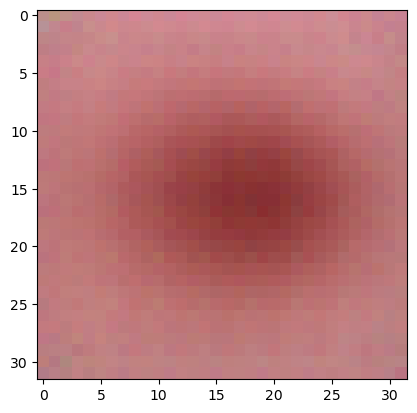

In [29]:
# Generar una imagen en el espacio latente a partir de ruido aleatorio
z = diffusion.sampling(model = unet, num_channels = latent_images.shape[1], n = 10)

import matplotlib.pyplot as plt

model.eval()

x_bar = model.decoder(z)

plt.imshow(x_bar[0].permute(1, 2, 0).cpu().detach().numpy())


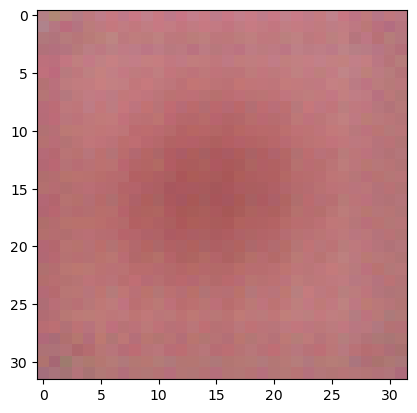

In [34]:
plt.imshow(x_bar[8].permute(1, 2, 0).cpu().detach().numpy())